## Rapport Traitement du Signal - Naudet Sybille et Thoumyre--Rivero Campoy Pablo ##

### Réponse à la question 3 ###

La fonction hachage est invariante par translation de $\Delta t$ car les fréquences sont les mêmes et $$(t_i+\Delta t)-(t_a+\Delta t)=t_i-t_a$$ De plus, si on décale dans le temps les extraits, les fréquences des signaux restent inchangées. Seul le temps absolu $t_a$ donc change réellement, mais il est stocké en dehors du hachage. 

### Réponse à la question 5 ###

Lorsque l'on fait correspondre deux sons parfaitements, les points $\tilde{t_a}$ et $t_a$ sont identiques, i.e. sur un graphique $\tilde{t_a}$ en abscisse et $t_a$ en ordonnée, on obtient une droite de pente 1. Mais globalement, on obtient une droite pour des sons qui se correspondent. 

Cela se traduit par un pic pour l'histogramme des offsets car le déclage $t_a-\tilde{t_a}$ est constant. Cet histogramme pour une correspondance effective peut présenter d'autres petits pics qui ne sont généralement représentatifs que du bruit de l'extrait. 

En revanche, pour un morceau qui ne correspond pas à l'extrait, on n'obtient donc que des petits pics aléatoires pour différentes valeurs d'offsets car les quantités $\tilde{t_a}$ et $t_a$ ne sont pas reliées (d'où l'offset $t_a-\tilde{t_a}$ est aléatoire).

On peut observer ces phénomènes sur des graphiques présentés dans le fichier. 

### Solution du Projet ###

Le son mystère correspond au son 602 et on le vérifie bien à l'oreille. 

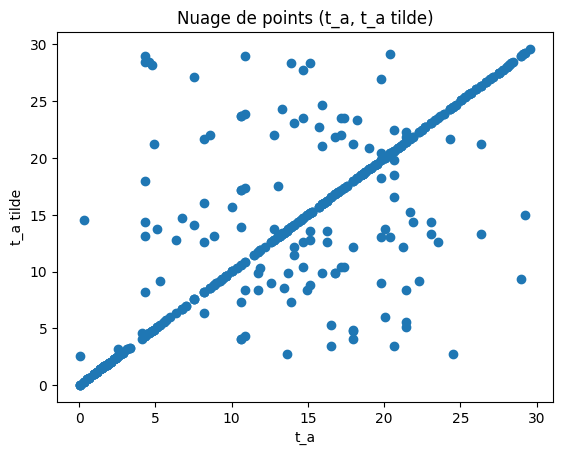

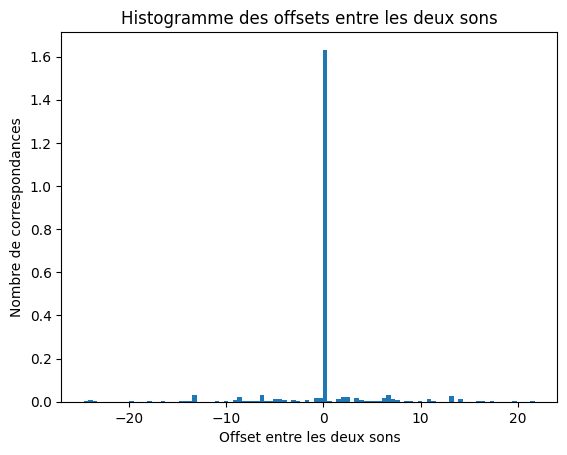

Les graphiques ci-dessus correspondent à un match True entre les deux sons


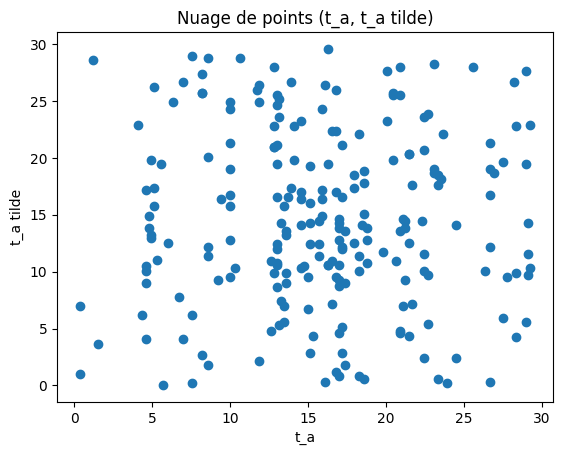

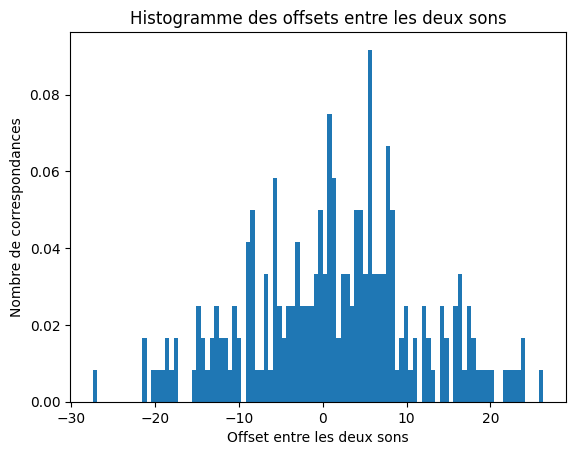

Les graphiques ci-dessus correspondent à un match False entre les deux sons
Le son maintenant choisi est le :  710 et on regarde le match entre un extrait de ce son et le son total


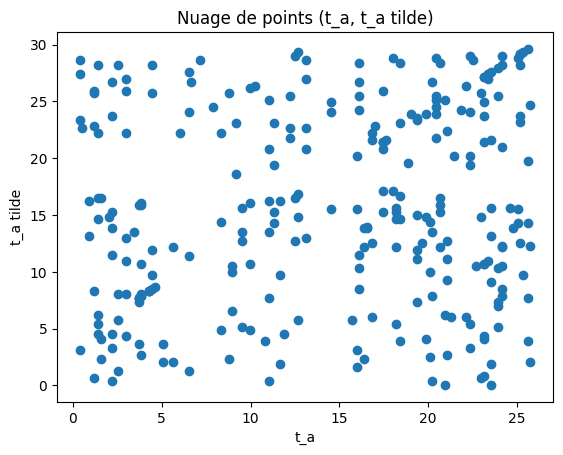

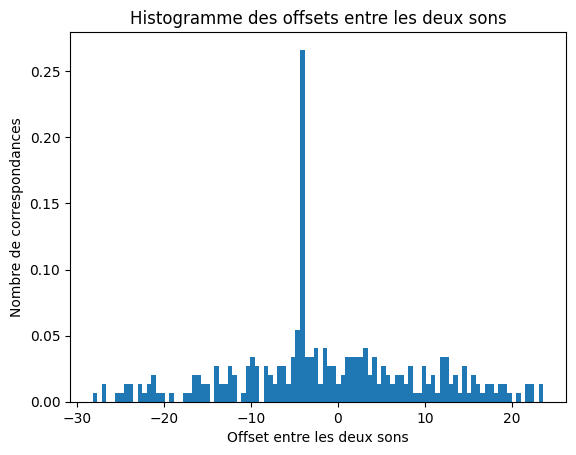

True
On fait l'étude désormais pour le son mystère 602


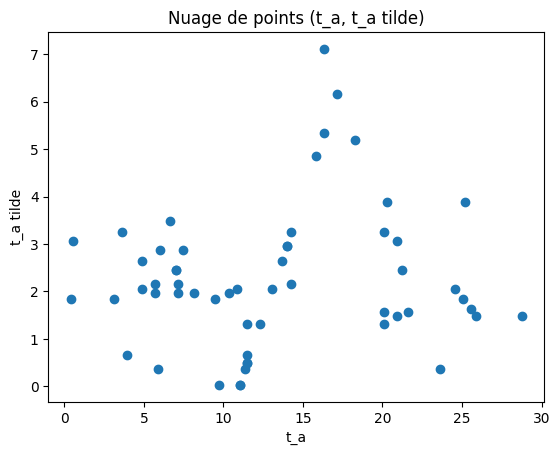

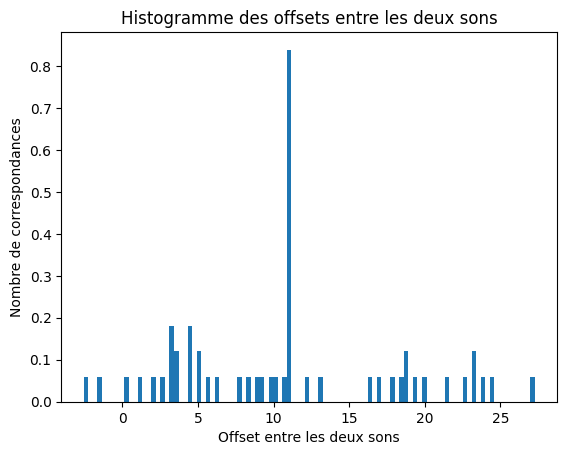

Le son mystère est le numéro :  ['602']


In [17]:
"""
Algorithm implementation
"""
import pickle
import numpy as np
import matplotlib.pyplot as plt

from scipy.io.wavfile import read
from scipy.signal import spectrogram
from skimage.feature import peak_local_max

# ----------------------------------------------------------------------------
# Create a fingerprint for an audio file based on a set of hashes
# ----------------------------------------------------------------------------


class Encoding:

    """
    Class implementing the procedure for creating a fingerprint 
    for the audio files

    The fingerprint is created through the following steps
    - compute the spectrogram of the audio signal
    - extract local maxima of the spectrogram
    - create hashes using these maxima

    """

    def __init__(self, nperseg=128, noverlap=32, min_distance=50, time_window=1, freq_window=1500):

        """
        Class constructor

        To Do
        -----

        Initialize in the constructor all the parameters required for
        creating the signature of the audio files. These parameters include for
        instance:
        - the window selected for computing the spectrogram
        - the size of the temporal window 
        - the size of the overlap between subsequent windows
        - etc.

        All these parameters should be kept as attributes of the class.
        """

        # Insert code here
        self.nperseg = nperseg
        self.noverlap = noverlap
        self.min_distance = min_distance
        self.time_window = time_window
        self.freq_window = freq_window



    

    def process(self, fs, s):

        """

        To Do
        -----

        This function takes as input a sampled signal s and the sampling
        frequency fs and returns the fingerprint (the hashcodes) of the signal.
        The fingerprint is created through the following steps
        - spectrogram computation
        - local maxima extraction
        - hashes creation

        Implement all these operations in this function. Keep as attributes of
        the class the spectrogram, the range of frequencies, the anchors, the 
        list of hashes, etc.

        Each hash can conveniently be represented by a Python dictionary 
        containing the time associated to its anchor (key: "t") and a numpy 
        array with the difference in time between the anchor and the target, 
        the frequency of the anchor and the frequency of the target 
        (key: "hash")


        Parameters
        ----------

        fs: int
           sampling frequency [Hz]
        s: numpy array
           sampled signal
        """

        self.fs = fs
        self.s = s

        # Insert code here

        if len(s.shape) > 1 and s.shape[1] > 1:
            s = np.mean(s, axis=1) #stéréo à mono

        self.f, self.t, self.S = spectrogram(s, fs=fs, nperseg=self.nperseg, noverlap=self.noverlap, scaling='spectrum')
        #on utilise peak_local_max pour ne garder que les maxima locaux
        self.anchors = peak_local_max(self.S, self.min_distance, exclude_border=False)

        self.hashes = []
        for f_a, t_a in self.anchors:
            for f_t, t_t in self.anchors:
                t = self.t[t_t] - self.t[t_a]
                f = abs(self.f[f_t] - self.f[f_a])
                if 0 < t <= self.time_window and f < self.freq_window:
                    self.hashes.append({"t": self.t[t_a], "hash": np.array([t, self.f[f_a], self.f[f_t]])})
        

    def display_spectrogram(self, display_anchors=False):
        """
        Display the spectrogram of the audio signal
        Parameters
        ----------
        display_anchors: boolean
           when set equal to True, the anchors are displayed on the
           spectrogram
        """
        plt.pcolormesh(self.t, self.f/1e3, self.S, shading='gouraud')
        plt.xlabel('Time [s]')
        plt.ylabel('Frequency [kHz]')
        if display_anchors and self.anchors is not None:
            plt.scatter([self.t[i] for i in self.anchors[:, 1]], [self.f[i]/1e3 for i in self.anchors[:, 0]])
        plt.show()


#on peut afficher un spectrogramme
if __name__ == '__main__':
    fs, s = read(r'C:\Users\thoum\Groupe_1_7_Optimisation\traitement du signal\samples\2.wav')
    encoder = Encoding()
    encoder.process(fs, s)
    #print(encoder.anchors)
    #print(encoder.t)
    #print([item['t'] for item in encoder.hashes])
    #encoder.display_spectrogram(True)

# ----------------------------------------------------------------------------
# Compares two set of hashes in order to determine if two audio files match
# ----------------------------------------------------------------------------

class Matching:

    """
    Compare the hashes from two audio files to determine if these
    files match

    Attributes
    ----------

    hashes1: list of dictionaries
       hashes extracted as fingerprints for the first audiofile. Each hash 
       is represented by a dictionary containing the time associated to
       its anchor (key: "t") and a numpy array with the difference in time
       between the anchor and the target, the frequency of the anchor and
       the frequency of the target (key: "hash")

    hashes2: list of dictionaries
       hashes extracted as fingerprint for the second audiofile. Each hash 
       is represented by a dictionary containing the time associated to
       its anchor (key: "t") and a numpy array with the difference in time
       between the anchor and the target, the frequency of the anchor and
       the frequency of the target (key: "hash")

    matching: numpy array
       absolute times of the hashes that match together

    offset: numpy array
       time offsets between the matches
    """

    def __init__(self, hashes1, hashes2, critere = 2):

        """
        Compare the hashes from two audio files to determine if these
        files match

        Parameters
        ----------

        hashes1: list of dictionaries
           hashes extracted as fingerprint for the first audiofile. Each hash 
           is represented by a dictionary containing the time associated to
           its anchor (key: "t") and a numpy array with the difference in time
           between the anchor and the target, the frequency of the anchor and
           the frequency of the target

        hashes2: list of dictionaries
           hashes extracted as fingerprint for the second audiofile. Each hash 
           is represented by a dictionary containing the time associated to
           its anchor (key: "t") and a numpy array with the difference in time
           between the anchor and the target, the frequency of the anchor and
           the frequency of the target
          
        """


        self.hashes1 = hashes1
        self.hashes2 = hashes2

        times = np.array([item['t'] for item in self.hashes1])
        hashcodes = np.array([item['hash'] for item in self.hashes1])

        # Establish matches
        self.matching = []
        for hc in self.hashes2:
             t = hc['t']
             h = hc['hash'][np.newaxis, :]
             dist = np.sum(np.abs(hashcodes - h), axis=1)
             mask = (dist < 1e-6)
             if (mask != 0).any():
                 self.matching.append(np.array([times[mask][0], t]))
        self.matching = np.array(self.matching)

        # TODO: complete the implementation of the class by
        # 1. creating an array "offset" containing the time offsets of the 
        #    hashcodes that match
        # 2. implementing a criterion to decide whether or not both extracts
        #    match

        self.match = False
        
        if self.matching.ndim > 1 and len(self.matching) > 1:
            self.offsets = self.matching[:,0] - self.matching[:,1]
            self.hist,_= np.histogram(self.offsets, bins=100) #on obtient 2 paramètres en sortie mais on a besoin que du 1e
            self.hist.sort()
            if self.hist[-1] > (critere * self.hist[-2]):
                self.match = True
              
    def display_scatterplot(self):
        """
        Display through a scatterplot the times associated to the hashes
        that match
        """
        plt.scatter(self.matching[:, 0], self.matching[:, 1])
        plt.xlabel("t_a")
        plt.ylabel("t_a tilde")
        plt.title("Nuage de points (t_a, t_a tilde)")
        plt.show()

    def display_histogram(self):
        """
        Display the offset histogram
        """
        plt.hist(self.offsets, bins=100, density=True)
        plt.xlabel('Offset entre les deux sons')
        plt.ylabel('Nombre de correspondances')
        plt.title("Histogramme des offsets entre les deux sons")
        plt.show()

if __name__ == '__main__':
    with open('C:/Users/thoum/Groupe_1_7_Optimisation/traitement du signal/songs3.pickle', 'rb') as handle:
        database = pickle.load(handle)

if __name__ == '__main__':
    matching = Matching(database[1]['hashcodes'], database[1]['hashcodes'])
    matching.display_scatterplot()
    matching.display_histogram()
    print(f"Les graphiques ci-dessus correspondent à un match {matching.match} entre les deux sons")

    matching = Matching(database[1]['hashcodes'], database[2]['hashcodes'])
    matching.display_scatterplot()
    matching.display_histogram()
    print(f"Les graphiques ci-dessus correspondent à un match {matching.match} entre les deux sons")

if __name__ == '__main__':
    song = np.random.randint(1,1001)
    print(f"Le son maintenant choisi est le :  {str(song)} et on regarde le match entre un extrait de ce son et le son total")
    dossier = 'C:/Users/thoum/Groupe_1_7_Optimisation/traitement du signal/samples/' + str(song) + '.wav' 
    
    fs, s = read(dossier)
    tstart = np.random.randint(1,10)
    tmin = int(tstart*fs)
    duree = int(30*fs)
    
    encoder.process(fs, s[tmin:tmin+duree])
    hashes1 = encoder.hashes

    encoder.process(fs, s)
    hashes2 = encoder.hashes
    
    matching = Matching(hashes1, hashes2)
    matching.display_scatterplot()
    matching.display_histogram()
    print(matching.match)

if __name__ == '__main__':
    #Données du pb 
    nperseg=128
    noverlap=32
    min_distance=25
    time_window=1.
    freq_window=1500
    encoder = Encoding(nperseg=nperseg, noverlap=noverlap, min_distance=min_distance,time_window=time_window, freq_window=freq_window)

    dossier = 'C:/Users/thoum/Groupe_1_7_Optimisation/traitement du signal/secret_sample.wav'
    fs, s = read(dossier)
    encoder.process(fs, s)
    hashes = encoder.hashes
    
    matchs = []
    for data in database:
        matching = Matching(data['hashcodes'], hashes, 4)
        if matching.match:
            print("On fait l'étude désormais pour le son mystère", data['song'])
            matchs.append(data['song'])
            matching.display_scatterplot()
            matching.display_histogram()
    print("Le son mystère est le numéro : ", matchs) 
#on trouve le son 602

#Si le code ne tourne pas voilà les résultats que l'on a obtenu : 

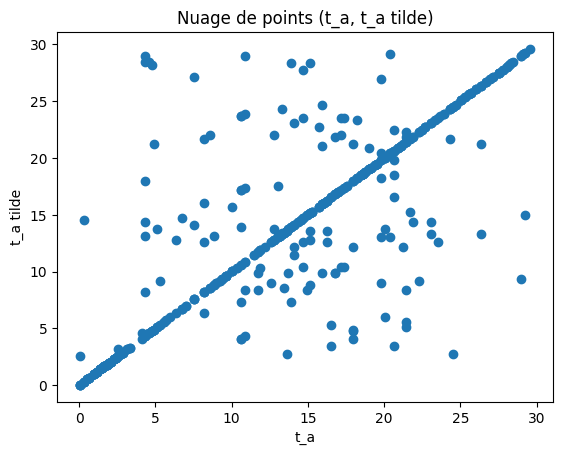
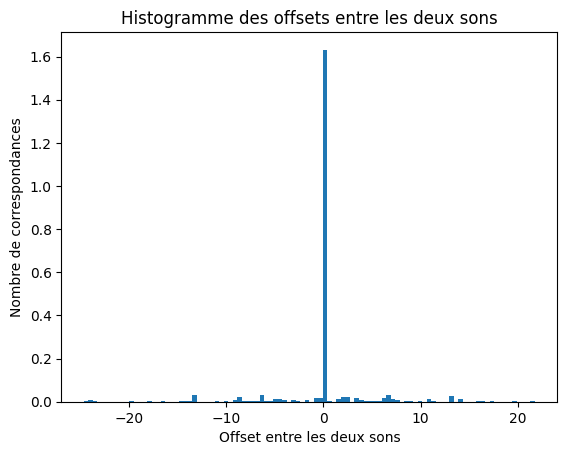

Les graphiques ci-dessus correspondent à un match True entre les deux sons


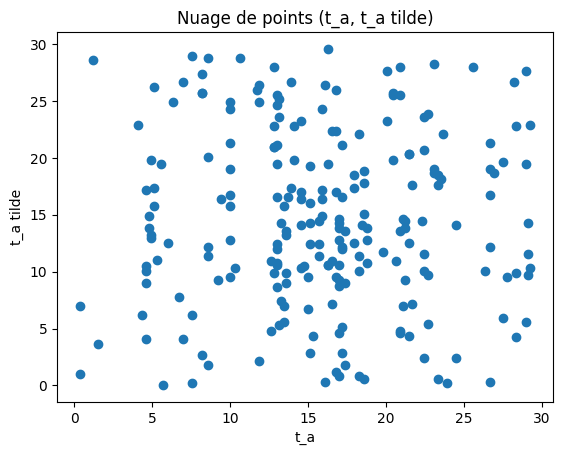
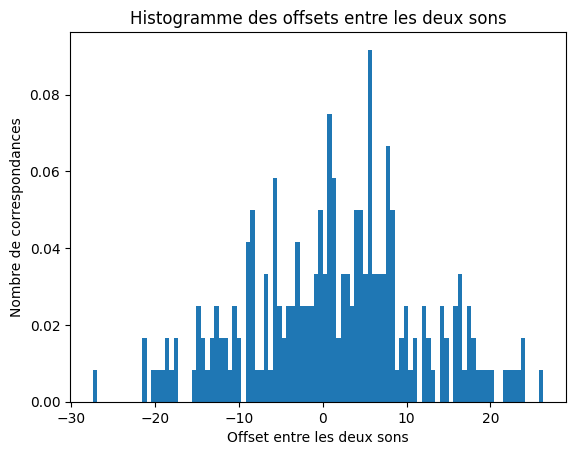

Les graphiques ci-dessus correspondent à un match False entre les deux sons

Le son maintenant choisi est le :  625 (mais c'est un choix aléatoire qui dépend de l'exécution) et on regarde le match entre un extrait de ce son et le son total

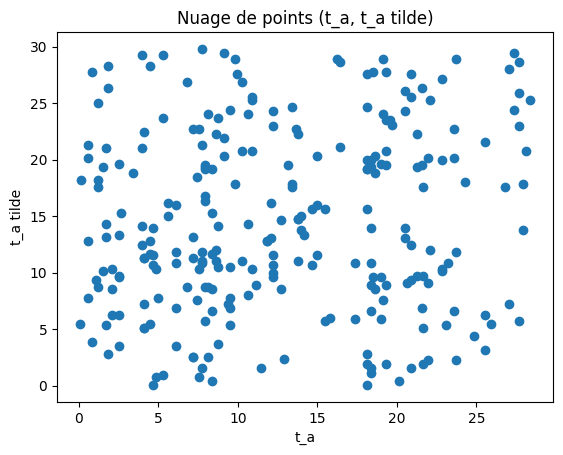
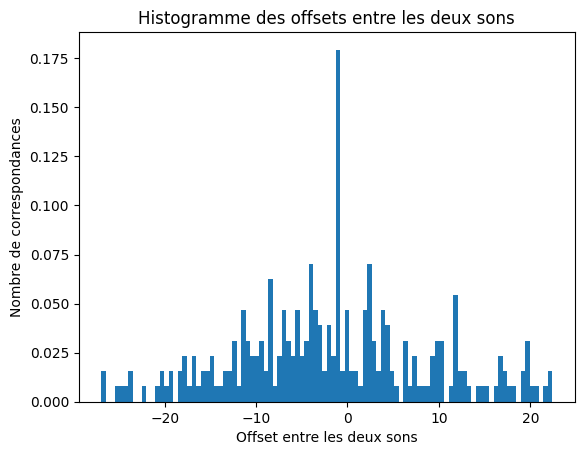

On fait l'étude désormais pour le son mystère

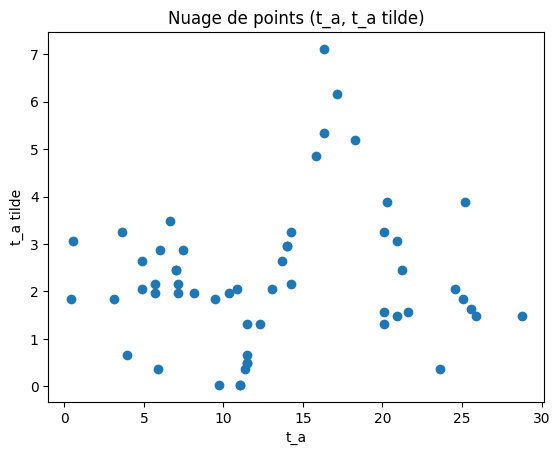
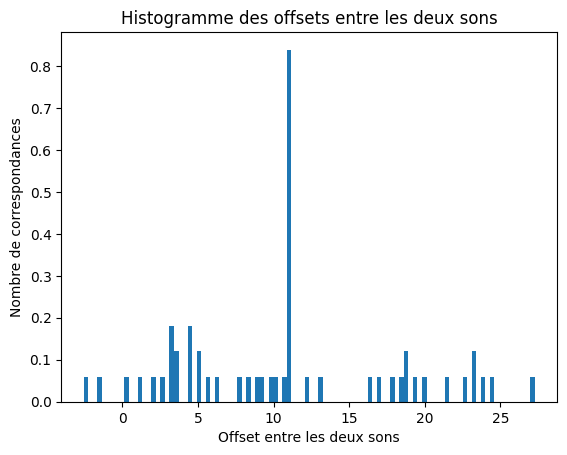

Le son mystère est le 602 !